Prédiction de l'iC-Apex par deep learning

Covariables attendues (rasters .tif au même SCR et résolution) :
  - alt        : altitude (m)
  - ru         : réserve utile (classes)
  - cwb_XXXX   : Climate Water Balance par année
 
Variable cible :
  - ic_apex    : indice de croissance des apexes (valeur continue)
 
Auteur : Thomas JUILLAC

# 0. IMPORTS

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm

# Geospatial libraries
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import box

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. LOAD APEX-VIGNE DATASET

1.1 LOAD DATASET

In [2]:
# Load the apex-vigne dataset
df = pd.read_csv('data/data_apex.csv', encoding='latin1', low_memory=False)

print(f"📊 Dataset shape: {df.shape[0]:,} observations × {df.shape[1]} columns")
print(f"\n🔤 Available columns:\n{df.columns.tolist()[:15]}...")

# Display first few rows
df.head(3)

📊 Dataset shape: 46,403 observations × 20 columns

🔤 Available columns:
['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude']...


,id_session,date_creation,date_maj,date_session,apex0,apex1,apex2,id_observateur,id_parcelle,id_stade,commentaire,device_hardware,device_software,longitude,latitude,location,en_parcelle,est_archivee,raison_archive,app_version
0,00020b39-e765-4337-999a-63e1f59aca46,2025-08-19 13:43:38,2025-08-19 13:43:38,2025-07-24,4,37,9,4e5e6f16-d26c-428e-a387-007533fa7be9,5843944e-d9d2-48cc-95c8-8d639807b031,NaN,NaN,iPhone,iOS 18.5,6.132792,45.550099,NaN,1.0,0,NaN,6.2.0
1,00041c61510442e5a64fb3af8ce11e24,2024-05-02 12:16:41,2025-04-18 08:46:16,2024-05-02,35,15,2,70c659af882b42ffb6b9415995434669,2f635c3720504254aebd2687712b0c8b,st-H-57-57,NaN,iPhone,iOS 17.4.1,3.544615,43.533837,NaN,1.0,0,NaN,NaN
2,0007ba68-e4f1-3fbd-82a9-336c7718bb2a,2020-06-25 04:27:02,2025-04-18 08:45:29,2019-07-10,13,31,6,edb6d513-eb76-4ad0-ae8a-0be7770048eb,5241d050-de2c-d5e5-a9f7-59f03c2e12ea,NaN,NaN,samsung SM-A715F,Android 11,NaN,NaN,NaN,0.0,0,NaN,NaN


1.2 FILTER ON DATE

In [3]:
#Filtrer les observations par date

# Paramètres à modifier
date_debut = "2025-07-14"
date_fin   = "2025-07-20"

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut) & (df['date_session'] <= date_fin)]

print(f"📅 Période sélectionnée : {date_debut} → {date_fin}")
print(f"📊 Observations totales  : {len(df):,}")
print(f"📊 Après filtrage        : {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\n📋 Période couverte par les données filtrées :")
print(f"   De : {df_filtered['date_session'].min().date()}")
print(f"   À  : {df_filtered['date_session'].max().date()}")

📅 Période sélectionnée : 2025-07-14 → 2025-07-20
📊 Observations totales  : 46,403
📊 Après filtrage        : 1,257 (2.7%)

📋 Période couverte par les données filtrées :
   De : 2025-07-14
   À  : 2025-07-20


1.3 FILTER ON LOCATION

In [4]:
# Conversion en objet spatial
data_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

In [5]:
# Filtrer les observations dans la zone d'étude
study_zone = gpd.read_file("data/study_zone.gpkg")
data_sf_proj = data_sf.to_crs(study_zone.crs)
data_zone = data_sf_proj[data_sf_proj.within(study_zone.union_all())]

data_zone = data_sf_proj[data_sf_proj.within(study_zone.union_all())].copy()

# Calcul de l'iG-APEX
data_zone['ig_apex'] = (data_zone['apex0'] + 0.5 * data_zone['apex1']) / (
    data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2']
)

print(f"📊 Avant filtre zone : {len(data_sf_proj):,} observations")
print(f"📊 Après filtre zone : {len(data_zone):,} observations")
print(f"   Soit {len(data_zone)/len(data_sf_proj)*100:.1f}% des observations retenues")

📊 Avant filtre zone : 1,247 observations
📊 Après filtre zone : 827 observations
   Soit 66.3% des observations retenues


# 2. DATA VISUALISATION (ALREADY DONE IN R)

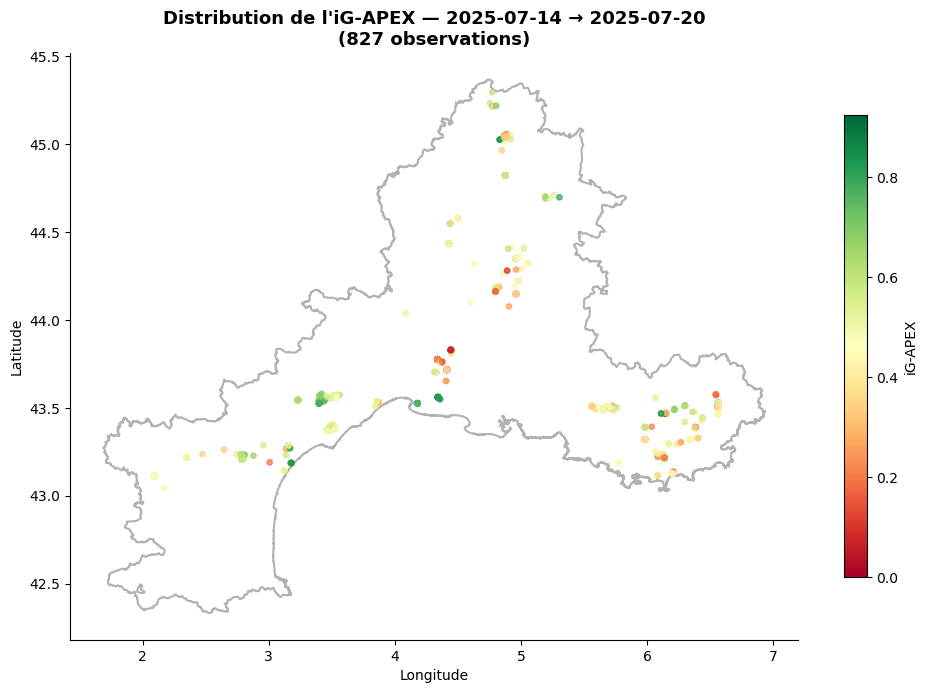

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Reprojection en WGS84 pour affichage cohérent
study_zone_wgs = study_zone.to_crs("EPSG:4326")
data_zone_wgs  = data_zone.to_crs("EPSG:4326")

# Contour de la zone d'étude
study_zone_wgs.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.3
)

# Points colorés par iG-APEX
data_zone_wgs.plot(
    ax=ax,
    column='ig_apex',
    cmap='RdYlGn',
    markersize=15,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'iG-APEX', 'shrink': 0.6}
)

ax.set_title(
    f"Distribution de l'iG-APEX — {date_debut} → {date_fin}\n"
    f"({len(data_zone_wgs):,} observations)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
print(data_zone.columns.tolist())

['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude', 'location', 'en_parcelle', 'est_archivee', 'raison_archive', 'app_version', 'geometry', 'ig_apex']


# 3. LOAD STUDY ZONE (GRID)

In [8]:
grid = gpd.read_file("data/study_zone_grid.gpkg")
grid.head()

,id,left,top,right,bottom,row_index,col_index,geometry
0,233,593491.216894,6.243619e+06,594491.216894,6.242619e+06,232,0,"MULTIPOLYGON (((594147.893 6242691.759, 594182..."
1,234,593491.216894,6.242619e+06,594491.216894,6.241619e+06,233,0,"MULTIPOLYGON (((594077.807 6241631.64, 594057...."
2,235,593491.216894,6.241619e+06,594491.216894,6.240619e+06,234,0,"MULTIPOLYGON (((594487.234 6240783.55, 594463...."
3,236,593491.216894,6.240619e+06,594491.216894,6.239619e+06,235,0,"MULTIPOLYGON (((594113.921 6239641.903, 594131..."
4,237,593491.216894,6.239619e+06,594491.216894,6.238619e+06,236,0,"MULTIPOLYGON (((594472.355 6239234.844, 594419..."


# 4. RASTERS

In [9]:
# Sélection des covariables CWB
CWB_MODE = "single"       # "none" | "single" | "multi"
CWB_YEAR = 2025          # utilisé seulement si CWB_MODE == "single"
CWB_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]  # utilisé seulement si CWB_MODE == "multi"

# Lister tous les rasters dans les sous-dossiers
subfolders = ['alt', 'ru']  # CWB géré séparément
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

# Ajout des fichiers CWB selon le mode
if CWB_MODE == "single":
    cwb_files = sorted(glob.glob(f'data/cov/rasters/cwb/ClimaticWaterBalance{CWB_YEAR}.tif'))
elif CWB_MODE == "multi":
    cwb_files = sorted([
        f'data/cov/rasters/cwb/ClimaticWaterBalance{yr}.tif'
        for yr in CWB_YEARS
        if glob.glob(f'data/cov/rasters/cwb/ClimaticWaterBalance{yr}.tif')
    ])
else:  # "none"
    cwb_files = []

raster_files.extend(cwb_files)

print(f"📂 {len(raster_files)} rasters trouvés (CWB mode: {CWB_MODE}) :\n")
for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

📂 3 rasters trouvés (CWB mode: single) :

   data/cov/rasters/alt\altitude_study_zone.tif
      Dimensions : 424 × 337 pixels
      Résolution : 1000 m

   data/cov/rasters/ru\ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m

   data/cov/rasters/cwb/ClimaticWaterBalance2025.tif
      Dimensions : 423 × 338 pixels
      Résolution : 1000 m



# 5. VISUALISATION OF COVARIABLES

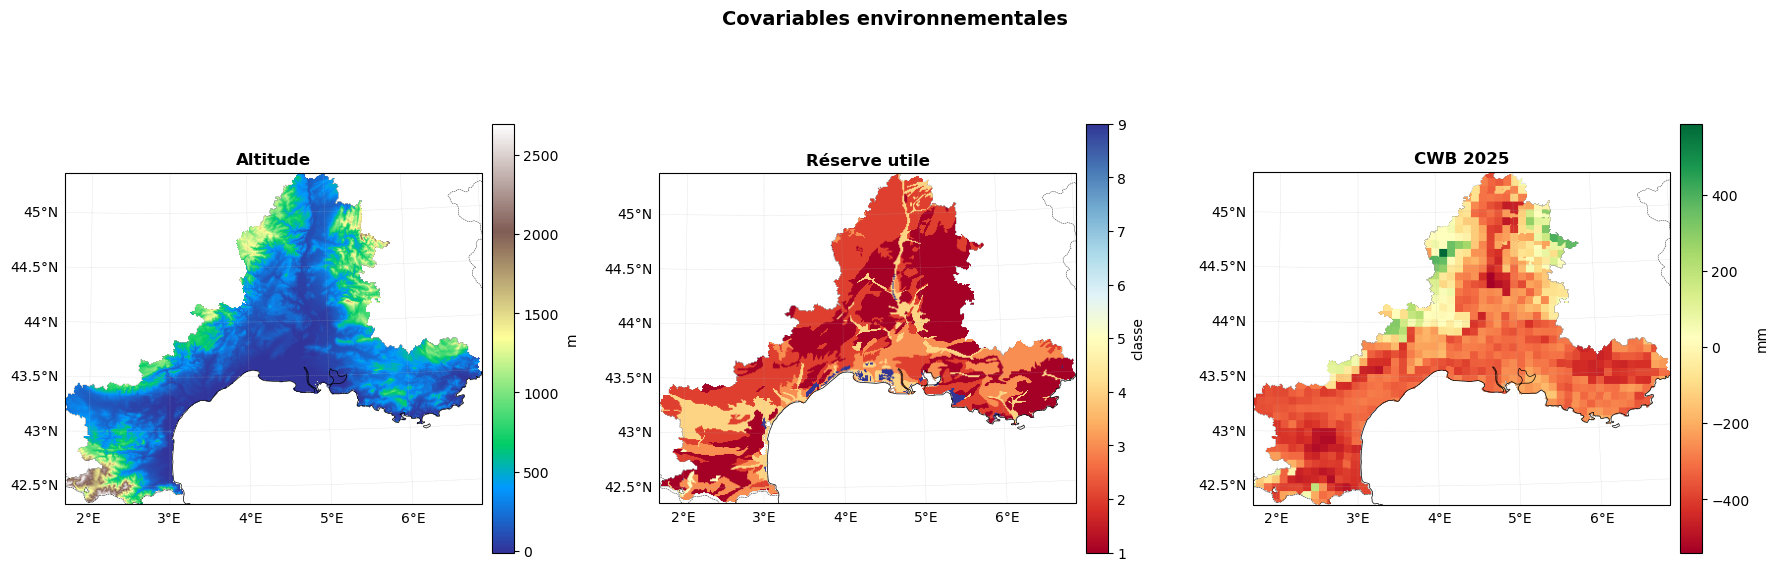

In [10]:
variables_to_plot = [
    ('data/cov/rasters/alt/altitude_study_zone.tif',          'Altitude',      'm',     'terrain'),
    ('data/cov/rasters/ru/ru_raster.tif',                     'Réserve utile', 'classe','RdYlBu'),
    ('data/cov/rasters/cwb/ClimaticWaterBalance2025.tif',      'CWB 2025',      'mm',    'RdYlGn'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={'projection': ccrs.epsg(2154)})

for ax, (filepath, title, unit, cmap) in zip(axes, variables_to_plot):
    with rasterio.open(filepath) as src:
        data   = src.read(1).astype(np.float32)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        nodata = src.nodata

        if nodata is not None:
            data = np.ma.masked_where((data == nodata) | ~np.isfinite(data), data)
        else:
            data = np.ma.masked_where(
                (data <= -9999) | (data == 0) | ~np.isfinite(data), data
            )

    ax.set_facecolor('none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle='--')

    im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap,
                   transform=ccrs.epsg(2154))

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(unit, fontsize=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Covariables environnementales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. PREPARE TRAINING DATA

6.1 RASTER PROPERTIES

In [11]:
# Get raster properties from the first raster
with rasterio.open(raster_files[0]) as src:
    raster_resolution = abs(src.transform[0])
    raster_transform  = src.transform
    raster_crs        = src.crs

print(f"📐 Résolution : {raster_resolution:.0f} m")
print(f"🌐 SCR : {raster_crs}")
print(f"📁 Nombre de variables : {len(raster_files)}")
print(f"\n📋 Variables :")
for i, f in enumerate(raster_files, 1):
    print(f"   {i:2d}. {os.path.basename(f)}")

📐 Résolution : 1000 m
🌐 SCR : EPSG:2154
📁 Nombre de variables : 3

📋 Variables :
    1. altitude_study_zone.tif
    2. ru_raster.tif
    3. ClimaticWaterBalance2025.tif


6.2 iG-APEX calculation

In [12]:
# Calcul de l'iG-APEX
data_zone = data_zone.copy()
data_zone['date_session'] = pd.to_datetime(data_zone['date_session']).dt.date
data_zone['ig_apex'] = (data_zone['apex0'] + data_zone['apex1'] * 0.5) / \
                       (data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2'])

print(f"📍 Observations brutes      : {len(df):,}")
print(f"📍 Après nettoyage spatial  : {len(data_sf):,}")
print(f"📍 Dans la zone d'étude     : {len(data_zone):,}")
print(f"\n📋 Aperçu iG-APEX :")
print(data_zone['ig_apex'].describe().round(3))

📍 Observations brutes      : 46,403
📍 Après nettoyage spatial  : 1,247
📍 Dans la zone d'étude     : 827

📋 Aperçu iG-APEX :
count    827.000
mean       0.466
std        0.184
min        0.000
25%        0.350
50%        0.481
75%        0.570
max        0.924
Name: ig_apex, dtype: float64


6.3 CREATION OF TENSORS

In [13]:
# Coordonnées des centroïdes de la grille en Lambert
grid_proj = grid.to_crs("EPSG:2154")
centroids = [(geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry]
num_cells = len(grid_proj)
num_variables = len(raster_files)

print(f"📍 Nombre de cellules : {num_cells:,}")
print(f"📁 Nombre de variables : {num_variables}")

# Tenseur X — valeurs environnementales
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)

print("\n🌡️ Extraction des valeurs des covariables...")
for var_idx, filepath in enumerate(tqdm(raster_files, desc="Processing rasters")):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(centroids)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

# Tenseur y — iG-APEX moyen par cellule de grille
print("\n🔢 Construction du tenseur y (iG-APEX par case)...")
data_zone_proj = data_zone.to_crs("EPSG:2154")
grid_with_idx = grid_proj.copy()
grid_with_idx['cell_idx'] = range(num_cells)

# Jointure spatiale observations -> cellules
joined = gpd.sjoin(data_zone_proj[['ig_apex', 'geometry']], 
                   grid_with_idx[['cell_idx', 'geometry']], 
                   how='left', predicate='within')

# Moyenne de l'iG-APEX par cellule
ig_mean = joined.groupby('cell_idx')['ig_apex'].mean()
ig_mean = ig_mean.dropna() # Supprimer les cellules où la moyenne est NaN
y_tensor = torch.zeros((num_cells,), dtype=torch.float32)
y_tensor[ig_mean.index] = torch.tensor(ig_mean.values, dtype=torch.float32)

# Masque pour les absences d'observation (à utiliser pour l'entraînement)
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ig_mean.index] = True

print(f"\n✅ Tenseurs créés !")
print(f"   X (covariables) : {X_tensor.shape}")
print(f"   y (iG-APEX moyen par cellule)   : {y_tensor.shape}")
print(f"   Cellules avec observations      : {(y_tensor > 0).sum().item():,} / {num_cells:,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")

📍 Nombre de cellules : 50,998
📁 Nombre de variables : 3

🌡️ Extraction des valeurs des covariables...


Processing rasters: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.44it/s]


🔢 Construction du tenseur y (iG-APEX par case)...

✅ Tenseurs créés !
   X (covariables) : torch.Size([50998, 3])
   y (iG-APEX moyen par cellule)   : torch.Size([50998])
   Cellules avec observations      : 197 / 50,998
   Cellules masquées (non observées) : 50,801 / 50,998


## 7. DATA QUALITY CHECK & STATISTICS

In [14]:
# Check for missing values
nan_mask = torch.isnan(X_tensor)
rows_with_nan = nan_mask.any(dim=1).sum().item()
total_nan = nan_mask.sum().item()

print(f"📈 Feature Statistics:")
for i, fname in enumerate(raster_files):
    var_name = fname.replace('data/cov/rasters/', '').replace('.tif', '')
    values = X_tensor[:, i]
    valid_values = values[~torch.isnan(values)]
    if len(valid_values) == 0:
        print(f"   {var_name}: ⚠️ aucune valeur valide")
    else:
        print(f"   {var_name}: min={valid_values.min():.1f}, max={valid_values.max():.1f}, mean={valid_values.mean():.1f}")

print(f"\n⚠️  Missing Values:")
print(f"   Cellules avec NaN : {rows_with_nan:,} / {num_cells:,} ({100*rows_with_nan/num_cells:.1f}%)")
print(f"   Total NaN         : {total_nan:,}")

📈 Feature Statistics:
   alt\altitude_study_zone: min=-11.1, max=2696.0, mean=407.9
   ru\ru_raster: min=1.0, max=9.0, mean=2.1
   cwb/ClimaticWaterBalance2025: min=-540.0, max=586.2, mean=-254.2

⚠️  Missing Values:
   Cellules avec NaN : 1,081 / 50,998 (2.1%)
   Total NaN         : 1,224


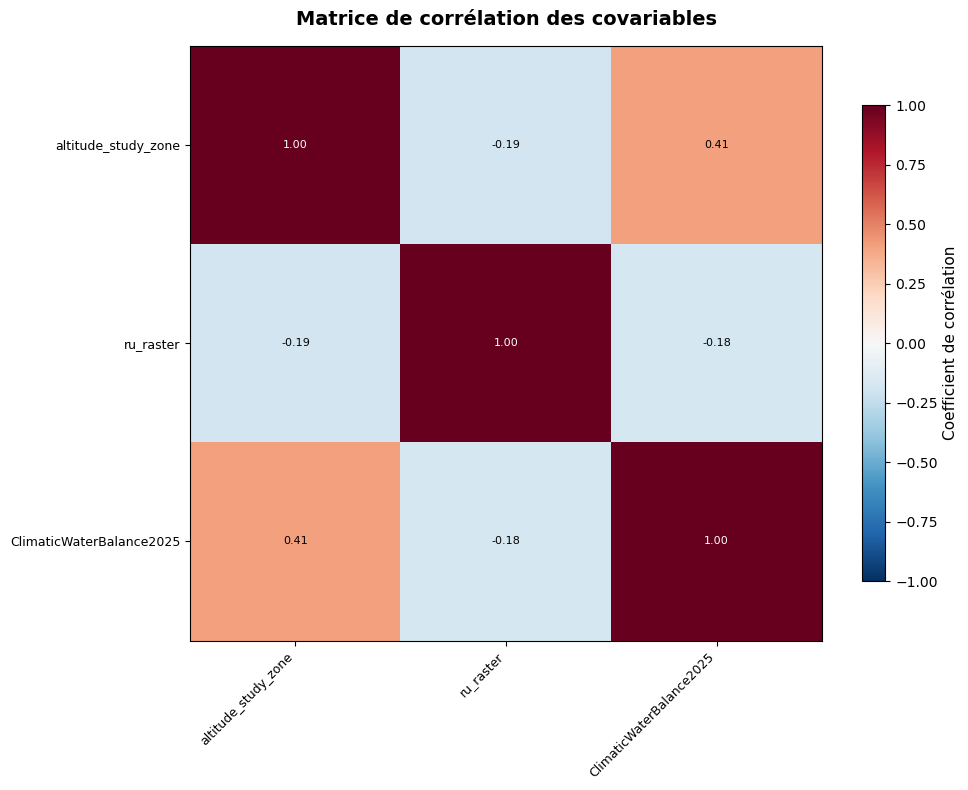


💡 Paires fortement corrélées (|r| > 0.8) :


In [15]:
# Correlation matrix of environmental variables
fig, ax = plt.subplots(figsize=(10, 8))

# Calcul de la matrice de corrélation (en ignorant les NaN)
X_numpy = X_tensor.numpy()
valid_mask = ~np.isnan(X_numpy).any(axis=1)
corr_matrix = np.corrcoef(X_numpy[valid_mask].T)

# Noms de variables nettoyés
var_names = [
    f.replace('data/cov/rasters/', '')
     .replace('alt\\', '').replace('cwb/', '').replace('ru\\', '')
     .replace('.tif', '')
    for f in raster_files
]

# Heatmap
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Coefficient de corrélation', fontsize=11)

# Annotations des valeurs dans chaque cellule
for i in range(len(var_names)):
    for j in range(len(var_names)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(corr_matrix[i, j]) < 0.7 else 'white')

ax.set_xticks(range(len(var_names)))
ax.set_yticks(range(len(var_names)))
ax.set_xticklabels(var_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(var_names, fontsize=9)
ax.set_title('Matrice de corrélation des covariables', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Paires fortement corrélées
print("\n💡 Paires fortement corrélées (|r| > 0.8) :")
for i in range(len(var_names)):
    for j in range(i+1, len(var_names)):
        if abs(corr_matrix[i, j]) > 0.8:
            print(f"   {var_names[i]} ↔ {var_names[j]} : r = {corr_matrix[i, j]:.2f}")

## 8. SPATIAL SPLIT FOR TEST/TRAINING

In [16]:
# Seuil de split spatial
LON_THRESHOLD = 3.2140200  # Longitude de Béziers

# Récupération des longitudes des cellules observées (WGS84)
grid_wgs84 = grid.to_crs("EPSG:4326")
longitudes_all = np.array([geom.centroid.x for geom in grid_wgs84.geometry])
longitudes_obs = longitudes_all[observed_mask.numpy()]

# Masques train / val
train_mask = longitudes_obs < LON_THRESHOLD
val_mask   = ~train_mask

# Split des tenseurs (sur cellules observées uniquement)
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]

X_train = X_obs[train_mask]
y_train = y_obs[train_mask]
X_val   = X_obs[val_mask]
y_val   = y_obs[val_mask]

print("🔀 SPATIAL BLOCK SPLIT")
print(f"📍 Seuil longitude : {LON_THRESHOLD}°")
print(f"\n📊 Split (sur {observed_mask.sum().item():,} cellules observées) :")
print(f"   Train (ouest) : {train_mask.sum():,} cellules ({100*train_mask.mean():.1f}%)")
print(f"   Val   (est)   : {val_mask.sum():,} cellules ({100*val_mask.mean():.1f}%)")
print(f"\n📐 Tensor shapes :")
print(f"   X_train : {X_train.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   y_val   : {y_val.shape}")

🔀 SPATIAL BLOCK SPLIT
📍 Seuil longitude : 3.21402°

📊 Split (sur 197 cellules observées) :
   Train (ouest) : 27 cellules (13.7%)
   Val   (est)   : 170 cellules (86.3%)

📐 Tensor shapes :
   X_train : torch.Size([27, 3])
   y_train : torch.Size([27])
   X_val   : torch.Size([170, 3])
   y_val   : torch.Size([170])


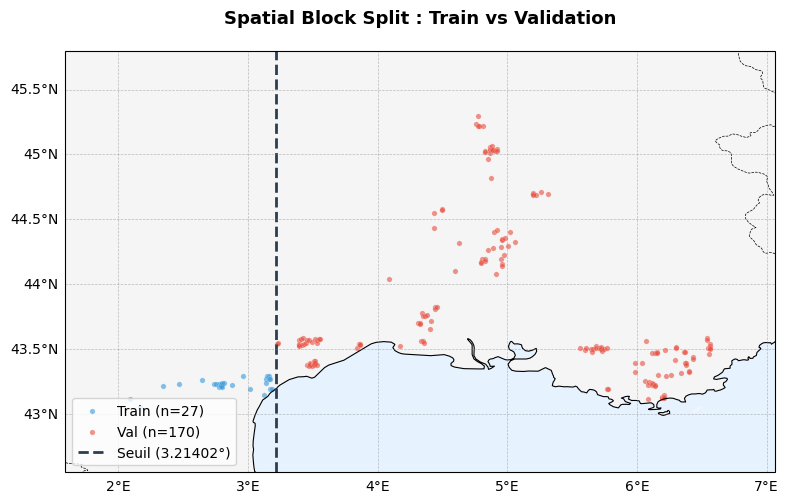

In [17]:
# Coordonnées WGS84 des cellules observées pour la carte
coords_obs = np.array([
    (grid_wgs84.geometry.iloc[i].centroid.x, grid_wgs84.geometry.iloc[i].centroid.y)
    for i in np.where(observed_mask.numpy())[0]
])
train_coords = coords_obs[train_mask]
val_coords   = coords_obs[val_mask]

# Carte du split spatial
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Extent de la zone d'étude
padding = 0.5
extent = [
    coords_obs[:, 0].min() - padding,
    coords_obs[:, 0].max() + padding,
    coords_obs[:, 1].min() - padding,
    coords_obs[:, 1].max() + padding
]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Fond de carte
ax.add_feature(cfeature.LAND,      facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN,     facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linestyle='--', linewidth=0.5)

# Points train / val
ax.scatter(train_coords[:, 0], train_coords[:, 1],
           c='#3498db', s=15, alpha=0.6, label=f'Train (n={len(train_coords):,})',
           transform=ccrs.PlateCarree(), edgecolor='white', linewidth=0.2)
ax.scatter(val_coords[:, 0], val_coords[:, 1],
           c='#e74c3c', s=15, alpha=0.6, label=f'Val (n={len(val_coords):,})',
           transform=ccrs.PlateCarree(), edgecolor='white', linewidth=0.2)

# Ligne de split
lat_min = coords_obs[:, 1].min() - padding
lat_max = coords_obs[:, 1].max() + padding
ax.plot([LON_THRESHOLD, LON_THRESHOLD], [lat_min, lat_max],
        color='#2c3e50', linestyle='--', linewidth=2,
        transform=ccrs.PlateCarree(), label=f'Seuil ({LON_THRESHOLD}°)')

# Grille
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False

ax.set_title('Spatial Block Split : Train vs Validation',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

## 9. MODEL TRAINING

9.1 DATA PREPROCESSING

In [18]:
# Suppression des cellules avec NaN dans les covariables
train_nan_mask = torch.isnan(X_train).any(dim=1)
val_nan_mask   = torch.isnan(X_val).any(dim=1)

X_train_clean = X_train[~train_nan_mask]
y_train_clean = y_train[~train_nan_mask]
X_val_clean   = X_val[~val_nan_mask]
y_val_clean   = y_val[~val_nan_mask]

print("🧹 Suppression des NaN...")
print(f"   Train : {train_nan_mask.sum().item()} cellules supprimées → {X_train_clean.shape[0]:,} restantes")
print(f"   Val   : {val_nan_mask.sum().item()} cellules supprimées → {X_val_clean.shape[0]:,} restantes")

# Normalisation des covariables (fit sur train uniquement)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean.numpy())
X_val_scaled   = scaler.transform(X_val_clean.numpy())

# Normalisation de la cible y (iG-APEX)
y_mean = y_train_clean.mean().item()
y_std  = y_train_clean.std().item()
y_train_scaled = (y_train_clean - y_mean) / y_std
y_val_scaled   = (y_val_clean   - y_mean) / y_std  # même paramètres que train

# Conversion en tenseurs
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32)
y_train_tensor = y_train_scaled
y_val_tensor   = y_val_scaled

print(f"\n📊 Statistiques de normalisation :")
print(f"   iG-APEX mean (train) : {y_mean:.4f}")
print(f"   iG-APEX std  (train) : {y_std:.4f}")

print(f"\n✅ Preprocessing terminé !")
print(f"   X_train_tensor : {X_train_tensor.shape}")
print(f"   y_train_tensor : {y_train_tensor.shape}")
print(f"   X_val_tensor   : {X_val_tensor.shape}")
print(f"   y_val_tensor   : {y_val_tensor.shape}")

🧹 Suppression des NaN...
   Train : 0 cellules supprimées → 27 restantes
   Val   : 0 cellules supprimées → 170 restantes

📊 Statistiques de normalisation :
   iG-APEX mean (train) : 0.5266
   iG-APEX std  (train) : 0.1447

✅ Preprocessing terminé !
   X_train_tensor : torch.Size([27, 3])
   y_train_tensor : torch.Size([27])
   X_val_tensor   : torch.Size([170, 3])
   y_val_tensor   : torch.Size([170])


9.2 MODEL CONFIGURATION AND TRAINING

In [19]:
# Additional imports for training
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# Training configuration
class Args:
    def __init__(self):
        self.learning_rate = 0.0001
        self.epoch         = 500
        self.hidden_nbr    = 1
        self.weight_decay  = 1e-2
        self.batch_size    = 32

args = Args()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")

# Paramètres du modèle
input_size  = X_train_tensor.shape[1]  # nb covariables
output_size = 1                         # iG-APEX (régression scalaire)
hidden_size = 32

print(f"\n🧠 Architecture du modèle :")
print(f"   Input  : {input_size} covariables")
print(f"   Hidden : {hidden_size} × {args.hidden_nbr} couches")
print(f"   Output : {output_size} (iG-APEX)")

print(f"\n⚙️  Configuration d'entraînement :")
print(f"   Learning rate : {args.learning_rate}")
print(f"   Epochs        : {args.epoch}")
print(f"   Weight decay  : {args.weight_decay}")
print(f"   Batch size    : {args.batch_size}")

🖥️  Device : cuda

🧠 Architecture du modèle :
   Input  : 3 covariables
   Hidden : 32 × 1 couches
   Output : 1 (iG-APEX)

⚙️  Configuration d'entraînement :
   Learning rate : 0.0001
   Epochs        : 500
   Weight decay  : 0.01
   Batch size    : 32


9.3 TRAINING LOOPS WITH VALIDATION RMSE

In [20]:
import torch.nn as nn

class mlp_model(nn.Module):
    """
    MLP pour la régression de l'iG-APEX.

    Args:
        input_size  : nombre de covariables
        hidden_size : nombre de neurones par couche cachée
        hidden_nbr  : nombre de couches cachées
    """
    def __init__(self, input_size, hidden_size, hidden_nbr):
        super(mlp_model, self).__init__()

        layers = []

        # Couche d'entrée
        layers += [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=0.2)
        ]

        # Couches cachées
        for _ in range(hidden_nbr - 1):
            layers += [
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(p=0.2)
            ]

        # Couche de sortie (régression → pas d'activation)
        layers.append(nn.Linear(hidden_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [21]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    """
    Entraînement d'un MLP pour la régression de l'iG-APEX.

    Returns:
        dict : modèle, historique des pertes, meilleur val_loss
    """
    # DataLoader
    train_dataset = TensorDataset(X_train, y_train)
    train_loader  = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)

    # Modèle, loss, optimizer
    input_size  = X_train.shape[1]
    model       = mlp_model(input_size, hidden_size, args.hidden_nbr).to(device)
    criterion   = nn.MSELoss()
    optimizer   = optim.Adam(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay
    )

    # Historique
    train_losses = []
    val_losses   = []
    best_val_loss    = float('inf')
    best_model_state = None

    print("🚀 Entraînement...")
    print("=" * 60)

    for epoch in tqdm(range(args.epoch), desc="Training"):

        # Phase train
        model.train()
        total_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss    = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Phase validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val.to(device)).squeeze()
            val_loss    = criterion(val_outputs, y_val.to(device)).item()
        val_losses.append(val_loss)

        # Log tous les 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            val_rmse = np.sqrt(val_loss)
            print(f"   Epoch {epoch+1:3d} | Train MSE: {avg_train_loss:.4f} | "
                  f"Val MSE: {val_loss:.4f} | Val RMSE: {val_rmse:.4f}")

        # Sauvegarde du meilleur modèle
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    # Rechargement du meilleur état
    if best_model_state is None:
        print("⚠️  Aucun meilleur modèle sauvegardé — val_loss était NaN/inf à chaque epoch")
        print("   Vérification des tenseurs d'entrée :")
        print(f"   X_train NaN : {torch.isnan(X_train).sum().item()}")
        print(f"   y_train NaN : {torch.isnan(y_train).sum().item()}")
        print(f"   y_train inf : {torch.isinf(y_train).sum().item()}")
        return None
    
    model.load_state_dict(best_model_state)
    # Rechargement du meilleur état
    model.load_state_dict(best_model_state)

    print("=" * 60)
    print(f"✅ Entraînement terminé ! Meilleur Val MSE : {best_val_loss:.4f} "
          f"| RMSE : {np.sqrt(best_val_loss):.4f}")

    return {
        "model"       : model,
        "train_losses": train_losses,
        "val_losses"  : val_losses,
        "best_val_loss": best_val_loss
    }

In [22]:
results = train_model(
    X_train     = X_train_tensor,
    y_train     = y_train_tensor,
    X_val       = X_val_tensor,
    y_val       = y_val_tensor,
    args        = args,
    hidden_size = hidden_size,
    device      = device
)

🚀 Entraînement...


Training:  11%|███████▌                                                              | 54/500 [00:00<00:02, 168.53it/s]

   Epoch   1 | Train MSE: 1.4366 | Val MSE: 2.0598 | Val RMSE: 1.4352
   Epoch  10 | Train MSE: 1.3606 | Val MSE: 2.4481 | Val RMSE: 1.5646
   Epoch  20 | Train MSE: 1.3420 | Val MSE: 2.9005 | Val RMSE: 1.7031
   Epoch  30 | Train MSE: 1.3362 | Val MSE: 3.2114 | Val RMSE: 1.7920
   Epoch  40 | Train MSE: 1.1535 | Val MSE: 3.3284 | Val RMSE: 1.8244
   Epoch  50 | Train MSE: 1.3371 | Val MSE: 3.2982 | Val RMSE: 1.8161
   Epoch  60 | Train MSE: 1.2371 | Val MSE: 3.2095 | Val RMSE: 1.7915
   Epoch  70 | Train MSE: 1.0783 | Val MSE: 3.1073 | Val RMSE: 1.7627
   Epoch  80 | Train MSE: 1.2379 | Val MSE: 2.9988 | Val RMSE: 1.7317
   Epoch  90 | Train MSE: 1.1913 | Val MSE: 2.8869 | Val RMSE: 1.6991
   Epoch 100 | Train MSE: 1.2560 | Val MSE: 2.7766 | Val RMSE: 1.6663
   Epoch 110 | Train MSE: 0.9643 | Val MSE: 2.6773 | Val RMSE: 1.6362


Training:  42%|████████████████████████████▊                                        | 209/500 [00:00<00:00, 391.05it/s]

   Epoch 120 | Train MSE: 1.1536 | Val MSE: 2.5794 | Val RMSE: 1.6060
   Epoch 130 | Train MSE: 1.1491 | Val MSE: 2.4870 | Val RMSE: 1.5770
   Epoch 140 | Train MSE: 1.0711 | Val MSE: 2.4038 | Val RMSE: 1.5504
   Epoch 150 | Train MSE: 1.2020 | Val MSE: 2.3162 | Val RMSE: 1.5219
   Epoch 160 | Train MSE: 0.9153 | Val MSE: 2.2359 | Val RMSE: 1.4953
   Epoch 170 | Train MSE: 1.2114 | Val MSE: 2.1673 | Val RMSE: 1.4722
   Epoch 180 | Train MSE: 1.1791 | Val MSE: 2.1087 | Val RMSE: 1.4521
   Epoch 190 | Train MSE: 1.0755 | Val MSE: 2.0515 | Val RMSE: 1.4323
   Epoch 200 | Train MSE: 1.1092 | Val MSE: 1.9941 | Val RMSE: 1.4121


...

   Epoch 300 | Train MSE: 1.0910 | Val MSE: 1.6096 | Val RMSE: 1.2687
   Epoch 310 | Train MSE: 0.9878 | Val MSE: 1.5919 | Val RMSE: 1.2617
   Epoch 320 | Train MSE: 0.8709 | Val MSE: 1.5813 | Val RMSE: 1.2575
   Epoch 330 | Train MSE: 0.8439 | Val MSE: 1.5702 | Val RMSE: 1.2531
   Epoch 340 | Train MSE: 0.9962 | Val MSE: 1.5576 | Val RMSE: 1.2480
   Epoch 350 | Train MSE: 0.8348 | Val MSE: 1.5440 | Val RMSE: 1.2426
   Epoch 360 | Train MSE: 1.1082 | Val MSE: 1.5358 | Val RMSE: 1.2393
   Epoch 370 | Train MSE: 0.9629 | Val MSE: 1.5293 | Val RMSE: 1.2366
   Epoch 380 | Train MSE: 1.0013 | Val MSE: 1.5259 | Val RMSE: 1.2353


Training:  96%|██████████████████████████████████████████████████████████████████   | 479/500 [00:01<00:00, 431.44it/s]

   Epoch 390 | Train MSE: 0.8723 | Val MSE: 1.5267 | Val RMSE: 1.2356
   Epoch 400 | Train MSE: 0.9689 | Val MSE: 1.5273 | Val RMSE: 1.2358
   Epoch 410 | Train MSE: 0.9966 | Val MSE: 1.5308 | Val RMSE: 1.2373
   Epoch 420 | Train MSE: 1.0700 | Val MSE: 1.5327 | Val RMSE: 1.2380
   Epoch 430 | Train MSE: 0.8518 | Val MSE: 1.5381 | Val RMSE: 1.2402
   Epoch 440 | Train MSE: 1.0303 | Val MSE: 1.5408 | Val RMSE: 1.2413
   Epoch 450 | Train MSE: 0.8596 | Val MSE: 1.5468 | Val RMSE: 1.2437
   Epoch 460 | Train MSE: 0.7817 | Val MSE: 1.5523 | Val RMSE: 1.2459
   Epoch 470 | Train MSE: 0.8927 | Val MSE: 1.5612 | Val RMSE: 1.2495


Training: 100%|█████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 354.70it/s]

   Epoch 480 | Train MSE: 0.9663 | Val MSE: 1.5684 | Val RMSE: 1.2524
   Epoch 490 | Train MSE: 0.9043 | Val MSE: 1.5776 | Val RMSE: 1.2560
   Epoch 500 | Train MSE: 0.8192 | Val MSE: 1.5907 | Val RMSE: 1.2612
✅ Entraînement terminé ! Meilleur Val MSE : 1.5258 | RMSE : 1.2352


9.4 VISUALISE TRAINING PROCESS

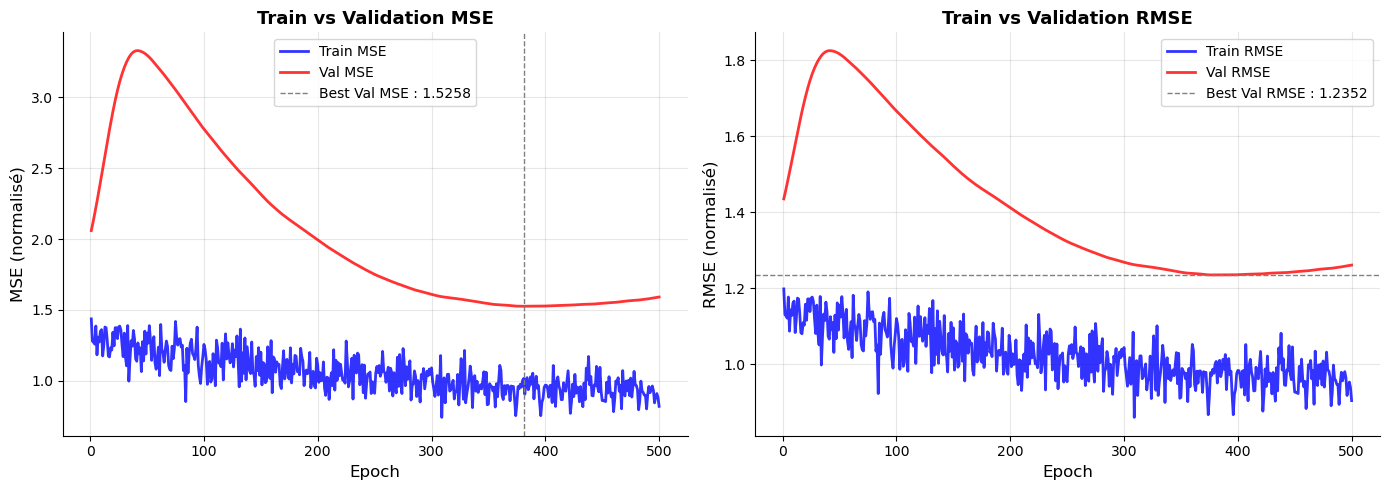


📊 MÉTRIQUES FINALES
   Train MSE  (dernière epoch) : 0.8192
   Val MSE    (dernière epoch) : 1.5907
   Val MSE    (meilleur)       : 1.5258
   Val RMSE   (meilleur)       : 1.2352


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(results['train_losses']) + 1)

# Courbe MSE
ax1 = axes[0]
ax1.plot(epochs, results['train_losses'], 'b-', linewidth=2, label='Train MSE', alpha=0.8)
ax1.plot(epochs, results['val_losses'],   'r-', linewidth=2, label='Val MSE',   alpha=0.8)
ax1.axvline(x=results['val_losses'].index(results['best_val_loss']) + 1,
            color='gray', linestyle='--', linewidth=1,
            label=f"Best Val MSE : {results['best_val_loss']:.4f}")
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE (normalisé)', fontsize=12)
ax1.set_title('Train vs Validation MSE', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Courbe RMSE
ax2 = axes[1]
train_rmse = [np.sqrt(v) for v in results['train_losses']]
val_rmse   = [np.sqrt(v) for v in results['val_losses']]
ax2.plot(epochs, train_rmse, 'b-', linewidth=2, label='Train RMSE', alpha=0.8)
ax2.plot(epochs, val_rmse,   'r-', linewidth=2, label='Val RMSE',   alpha=0.8)
ax2.axhline(y=np.sqrt(results['best_val_loss']), color='gray', linestyle='--', linewidth=1,
            label=f"Best Val RMSE : {np.sqrt(results['best_val_loss']):.4f}")
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('RMSE (normalisé)', fontsize=12)
ax2.set_title('Train vs Validation RMSE', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n📊 MÉTRIQUES FINALES")
print("=" * 50)
print(f"   Train MSE  (dernière epoch) : {results['train_losses'][-1]:.4f}")
print(f"   Val MSE    (dernière epoch) : {results['val_losses'][-1]:.4f}")
print(f"   Val MSE    (meilleur)       : {results['best_val_loss']:.4f}")
print(f"   Val RMSE   (meilleur)       : {np.sqrt(results['best_val_loss']):.4f}")

9.5 EVALUATION

In [24]:
# Dénormalisation des prédictions pour interpréter en unités iG-APEX réelles
model = results["model"]
model.eval()

with torch.no_grad():
    val_preds_scaled = model(X_val_tensor.to(device)).squeeze().cpu()

# Dénormalisation
val_preds = val_preds_scaled * y_std + y_mean
val_true  = y_val_tensor     * y_std + y_mean

# Métriques en unités réelles
mse  = nn.MSELoss()(val_preds, val_true).item()
rmse = np.sqrt(mse)
mae  = torch.mean(torch.abs(val_preds - val_true)).item()
ss_res = torch.sum((val_true - val_preds) ** 2).item()
ss_tot = torch.sum((val_true - val_true.mean()) ** 2).item()
r2 = 1 - ss_res / ss_tot

print(f"📊 Évaluation sur le set de validation (unités iG-APEX) :")
print(f"   RMSE : {rmse:.4f}")
print(f"   MAE  : {mae:.4f}")
print(f"   R²   : {r2:.4f}")

📊 Évaluation sur le set de validation (unités iG-APEX) :
   RMSE : 0.1787
   MAE  : 0.1421
   R²   : -0.4935


In [25]:
# Est-ce que les covariables sont réellement prédictives ?
# Corrélation simple entre chaque covariable et y sur le train

train_true = y_train_tensor * y_std + y_mean

print("📊 Corrélations covariables → iG-APEX (train) :")
var_names = [
    f.replace('data/cov/rasters/', '')
     .replace('alt/', '').replace('cwb/', '').replace('ru/', '')
     .replace('.tif', '')
    for f in raster_files
]
for i, name in enumerate(var_names):
    x_col = X_train_tensor[:, i]
    # ignorer NaN éventuels
    mask = ~torch.isnan(x_col)
    corr = np.corrcoef(x_col[mask].numpy(), train_true[mask].numpy())[0, 1]
    print(f"   {name:40s} r = {corr:.3f}")

📊 Corrélations covariables → iG-APEX (train) :
   alt\altitude_study_zone                  r = -0.195
   ru\ru_raster                             r = 0.282
   ClimaticWaterBalance2025                 r = -0.068


## 10. GENERATE IG-APEX MAP

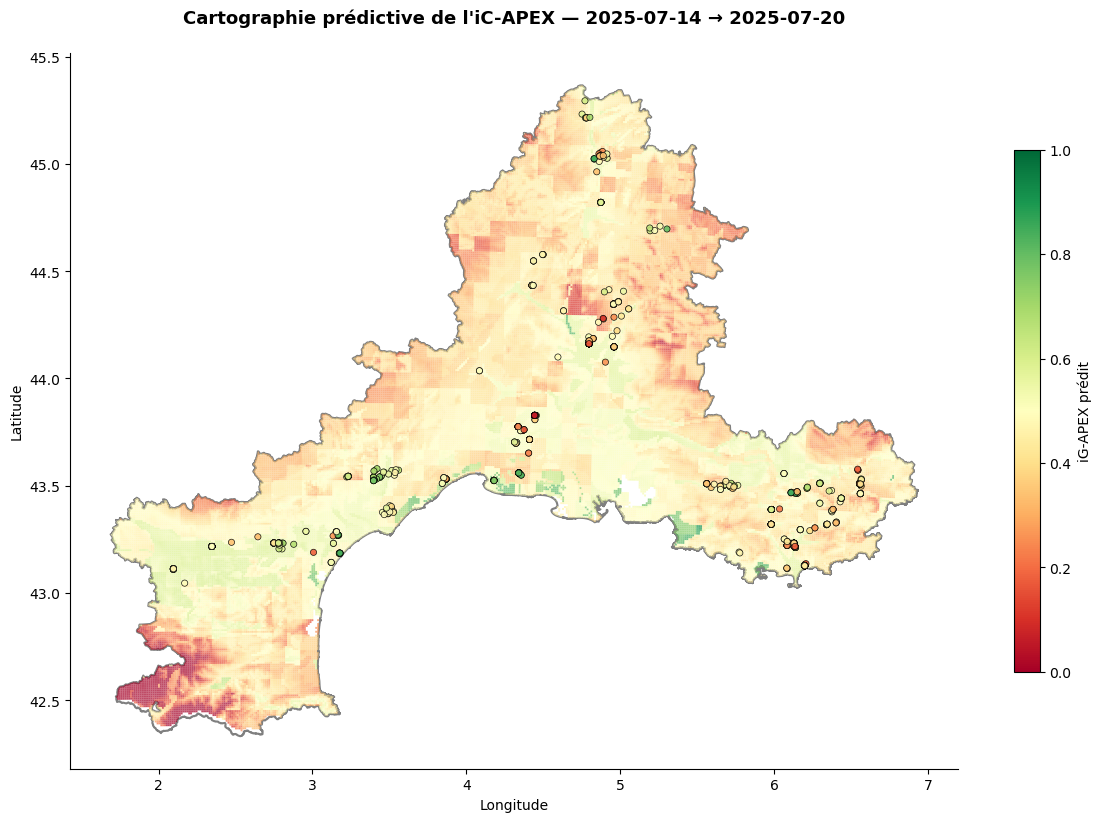


📊 Statistiques des prédictions :
   Cellules prédites : 49,917 / 50,998
   min  : -0.353
   max  : 0.918
   mean : 0.417
   std  : 0.116


In [26]:
# Prédiction sur toutes les cellules de la grille (y compris non observées)
model = results["model"]
model.eval()

# 1. Suppression des cellules avec NaN dans les covariables
full_nan_mask = torch.isnan(X_tensor).any(dim=1)
X_full_clean  = X_tensor[~full_nan_mask]
valid_indices = torch.where(~full_nan_mask)[0]

# 2. Normalisation avec le scaler fitté sur le train
X_full_scaled  = scaler.transform(X_full_clean.numpy())
X_full_tensor  = torch.tensor(X_full_scaled, dtype=torch.float32)

# 3. Prédiction
with torch.no_grad():
    preds_scaled = model(X_full_tensor.to(device)).squeeze().cpu()

# 4. Dénormalisation
preds_igapex = preds_scaled * y_std + y_mean

# 5. Reconstruction sur toute la grille (NaN pour les cellules invalides)
pred_full = torch.full((num_cells,), float('nan'))
pred_full[valid_indices] = preds_igapex

# 6. Carte
grid_wgs84 = grid.to_crs("EPSG:4326")
grid_pred  = grid_wgs84.copy()
grid_pred['ig_apex_pred'] = pred_full.numpy()

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

study_zone_wgs = study_zone.to_crs("EPSG:4326")
study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)

grid_pred.dropna(subset=['ig_apex_pred']).plot(
    ax=ax,
    column='ig_apex_pred',
    cmap='RdYlGn',
    legend=True,
    alpha=0.7,
    legend_kwds={'label': 'iG-APEX prédit', 'shrink': 0.6},
    vmin=0, vmax=1
)

# Points d'observation réels par dessus
data_zone_wgs = data_zone.to_crs("EPSG:4326")
data_zone_wgs.plot(
    ax=ax,
    column='ig_apex',
    cmap='RdYlGn',
    markersize=20,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9,
    legend=False,
    vmin=0, vmax=1
)

ax.set_title(
    f"Cartographie prédictive de l'iC-APEX — {date_debut} → {date_fin}\n",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques des prédictions :")
valid_preds = pred_full[~torch.isnan(pred_full)]
print(f"   Cellules prédites : {len(valid_preds):,} / {num_cells:,}")
print(f"   min  : {valid_preds.min():.3f}")
print(f"   max  : {valid_preds.max():.3f}")
print(f"   mean : {valid_preds.mean():.3f}")
print(f"   std  : {valid_preds.std():.3f}")